DPA sanity check for SDP model outputs in Gulf Stream area.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

data_dir = "/Users/jerry/Desktop/school/research/eddy-tracking/outputs/gulf_stream_20241001_20250701"

In [43]:
def load_pigments(polarity):
    fps = glob(f"{data_dir}/pigments/{polarity}/*.parquet")
    dfs = [pd.read_parquet(fp) for fp in fps]
    combined = pd.concat(dfs, ignore_index=True)
    combined["polarity"] = polarity
    return combined

df = pd.concat(
    [load_pigments("cyclone"), load_pigments("anticyclone")],
    ignore_index=True,
)
print(f"{len(df):,} pixel observations")
df["polarity"].value_counts()

471,305 pixel observations


polarity
cyclone        305553
anticyclone    165752
Name: count, dtype: int64

In [44]:
# Uitz et al. (2006) DPA coefficients
dpa_weights = {
    "Fuco": 1.41, "Perid": 1.41, "HexFuco": 1.27,
    "ButFuco": 0.35, "Allo": 0.60, "MV chlb": 1.01, "Zea": 0.86,
}

df["dpa_tchla"] = sum(w * df[pig] for pig, w in dpa_weights.items())

residual = df["dpa_tchla"] - df["T chla"]
r2 = 1 - (residual ** 2).sum() / ((df["T chla"] - df["T chla"].mean()) ** 2).sum()
rmse = np.sqrt((residual ** 2).mean())
bias = residual.mean()
print(f"R² = {r2:.4f},  RMSE = {rmse:.4f} µg/L,  Bias = {bias:.4f} µg/L")

R² = 0.9389,  RMSE = 0.0828 µg/L,  Bias = -0.0338 µg/L


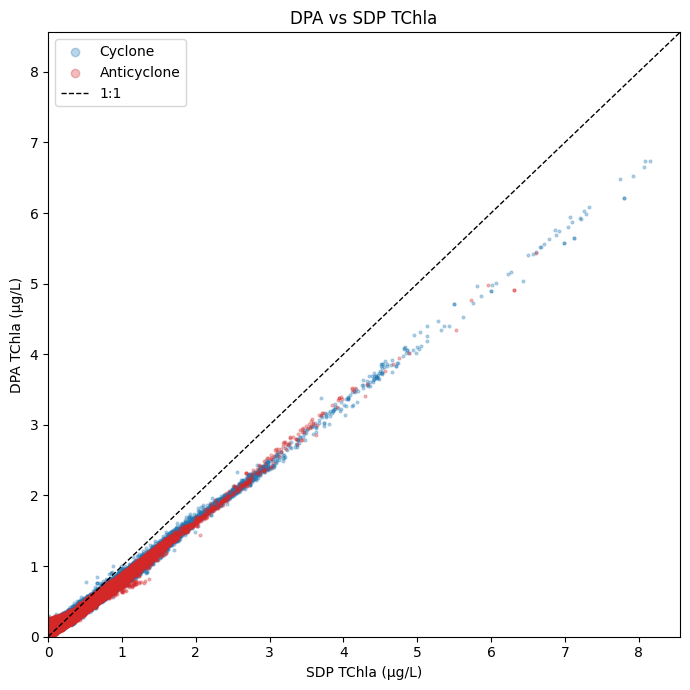

In [45]:
cyc = df[df["polarity"] == "cyclone"]
anti = df[df["polarity"] == "anticyclone"]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cyc["T chla"], cyc["dpa_tchla"], s=4, alpha=0.3, c="#1f77b4", label="Cyclone")
ax.scatter(anti["T chla"], anti["dpa_tchla"], s=4, alpha=0.3, c="#d62728", label="Anticyclone")

lims = [0, max(df["T chla"].max(), df["dpa_tchla"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("SDP TChla (µg/L)")
ax.set_ylabel("DPA TChla (µg/L)")
ax.set_title("DPA vs SDP TChla")
ax.legend(markerscale=3)
plt.tight_layout()

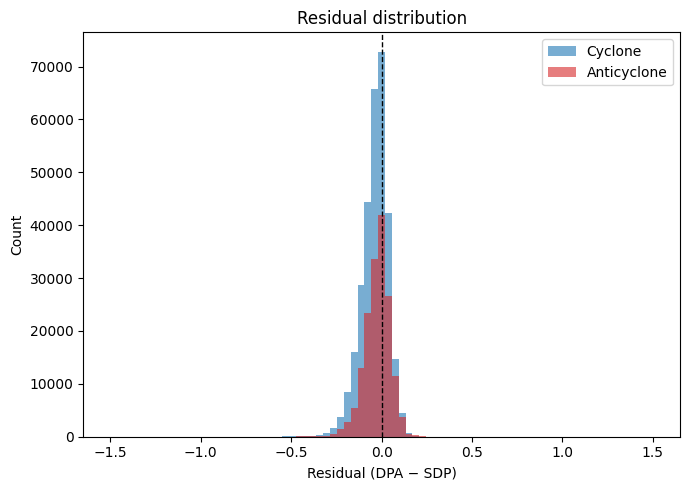

In [46]:
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(-1.5, 1.5, 80)
ax.hist(cyc["dpa_tchla"] - cyc["T chla"], bins=bins, alpha=0.6, color="#1f77b4", label="Cyclone")
ax.hist(anti["dpa_tchla"] - anti["T chla"], bins=bins, alpha=0.6, color="#d62728", label="Anticyclone")
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_xlabel("Residual (DPA − SDP)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution")
ax.legend()
plt.tight_layout()

## PFT sum check

Second consistency check: do the 6 Phytoclass PFT fractions (in Chla units) sum back to SDP TChla?

In [47]:
def load_pfts(polarity):
    fps = glob(f"{data_dir}/pft/{polarity}/*.parquet")
    dfs = [pd.read_parquet(fp) for fp in fps]
    combined = pd.concat(dfs, ignore_index=True)
    combined["polarity"] = polarity
    return combined

pft_df = pd.concat(
    [load_pfts("cyclone"), load_pfts("anticyclone")],
    ignore_index=True,
)

pft_cols = ["Diatoms", "Dinoflagellates", "Haptophytes", "Cryptophytes", "Green_algae", "Cyanobacteria"]
pft_df["pft_sum"] = pft_df[pft_cols].sum(axis=1)

# merge with pigment data to get SDP TChla on the same rows
merge_keys = ["track_id", "date", "pixel_lon", "pixel_lat", "polarity"]
merged = pft_df.merge(df[merge_keys + ["T chla"]], on=merge_keys)
print(f"{len(merged):,} matched pixel observations")

410,456 matched pixel observations


R² = 0.9991,  RMSE = 0.0102 µg/L,  Bias = 0.0019 µg/L


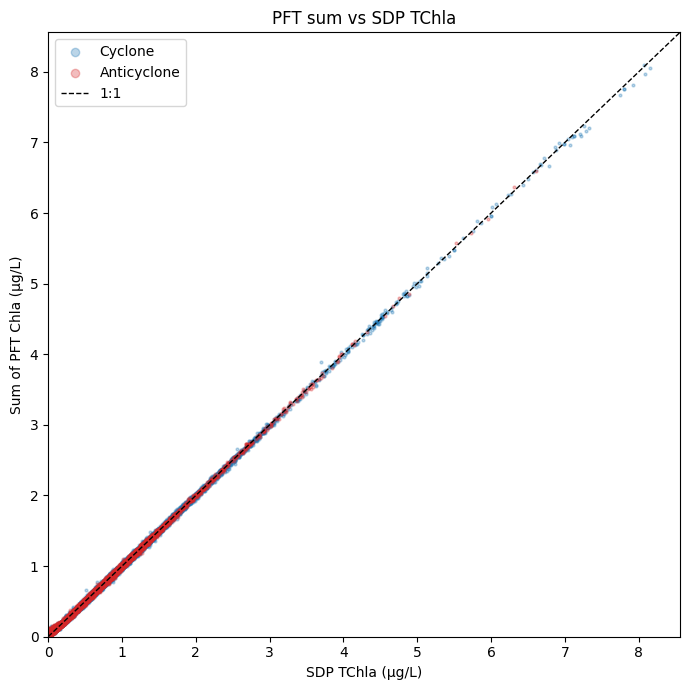

In [50]:
cyc_m = merged[merged["polarity"] == "cyclone"]
anti_m = merged[merged["polarity"] == "anticyclone"]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cyc_m["T chla"], cyc_m["pft_sum"], s=4, alpha=0.3, c="#1f77b4", label="Cyclone")
ax.scatter(anti_m["T chla"], anti_m["pft_sum"], s=4, alpha=0.3, c="#d62728", label="Anticyclone")

lims = [0, max(merged["T chla"].max(), merged["pft_sum"].max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("SDP TChla (µg/L)")
ax.set_ylabel("Sum of PFT Chla (µg/L)")
ax.set_title("PFT sum vs SDP TChla")
ax.legend(markerscale=3)

residual_pft = merged["pft_sum"] - merged["T chla"]
r2_pft = 1 - (residual_pft ** 2).sum() / ((merged["T chla"] - merged["T chla"].mean()) ** 2).sum()
rmse_pft = np.sqrt((residual_pft ** 2).mean())
bias_pft = residual_pft.mean()
print(f"R² = {r2_pft:.4f},  RMSE = {rmse_pft:.4f} µg/L,  Bias = {bias_pft:.4f} µg/L")
plt.tight_layout()